In [1]:
!pip install vitaldb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 95.2 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, ndimage
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import RobustScaler
import pywt

import vitaldb as v

# Preprocessing

In [3]:
track_names = ["SNUADC/ART",        # Arterial pressure wave  | W/500 | mmHg
               "SNUADC/ECG_II",     # ECG lead II wave        | W/500 | mV
               "SNUADC/ECG_V5",     # ECG lead V5 wave        | W/500 | mV
               "BIS/EEG1_WAV",      # EEG wave from channel 1 | W/128 | uV
               "BIS/EEG2_WAV",      # EEG wave from channel 2 | W/128 | uV
               "Solar8000/RR_CO2",  # Respiratory rate based on capnography | N | /min
               "Primus/CO2",        # Capnography wave        | W/62.5 | mmHg
               "BIS/BIS",           # Bispectral index value  |    N   | unitless
               ]

p = v.VitalFile(1, track_names)  # should we add max length?
p = p.to_pandas(track_names=track_names, interval=1/128)
p.columns = ['arterial_pres', 'ecg1', 'ecg2', 'eeg1', 'eeg2', 'resp_rate', 'capnography', 'bis']

### Band-pass filters

In [6]:
p.eeg1.describe()

count    1.477104e+06
mean     2.550321e+01
std      1.272642e+02
min     -1.474900e+03
25%      1.470000e+01
50%      2.510000e+01
75%      3.565000e+01
max      1.798550e+03
Name: eeg1, dtype: float64

Text(0.5, 1.0, 'Raw EEG1')

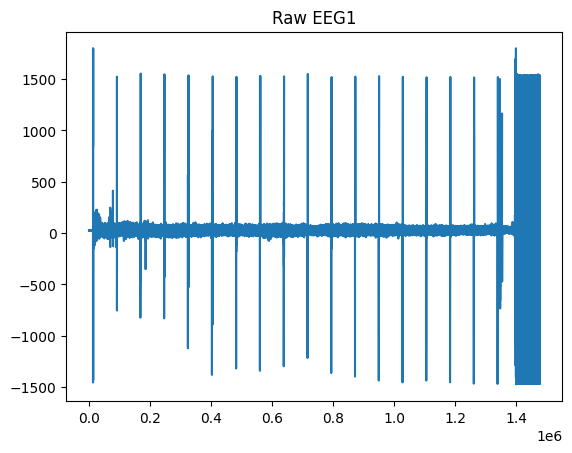

In [7]:
plt.plot(p.eeg1)
plt.title('Raw EEG1')

Text(0.5, 1.0, 'Butter-filtered')

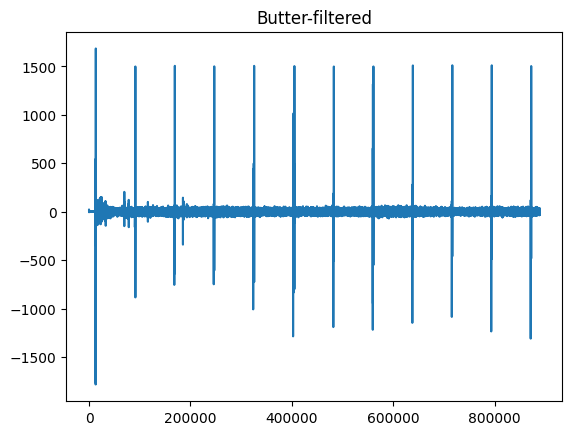

In [8]:
sos = signal.butter(2, [0.5, 40], 'bandpass', fs=128, output='sos')
eeg1_filtered = signal.sosfilt(sos, p.eeg1)
plt.plot(eeg1_filtered)
plt.title('Butter-filtered')

In [9]:
pd.DataFrame(eeg1_filtered).describe()

,0
count,889584.000000
mean,0.000006
std,23.867106
min,-1782.832517
25%,-7.885877
50%,-0.002491
75%,7.899411
max,1684.926964


In [10]:
eeg1_filtered.shape

(1477261,)

In [11]:
eeg1_filtered.reshape(-1,1)

array([[ 9.36106647],
       [23.51507748],
       [23.57508517],
       ...,
       [        nan],
       [        nan],
       [        nan]])

### Scaling

In [12]:

scaler = RobustScaler(quantile_range=(0.25, 0.75))
eeg1_scaled = scaler.fit_transform(eeg1_filtered.reshape(-1,1))

Text(0.5, 1.0, 'Robust Scaling')

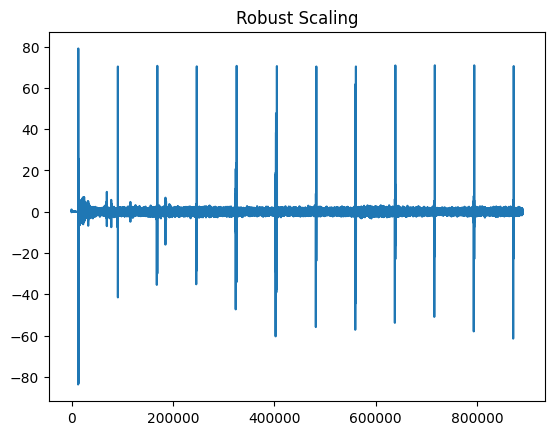

In [13]:
plt.plot(eeg1_scaled)
plt.title('Robust Scaling')

In [14]:
pd.DataFrame(eeg1_scaled).describe()

,0
count,889584.000000
mean,0.000117
std,1.120030
min,-83.664232
25%,-0.369950
50%,0.000000
75%,0.370819
max,79.069977


### Frequency Analysis

example of a spectogram

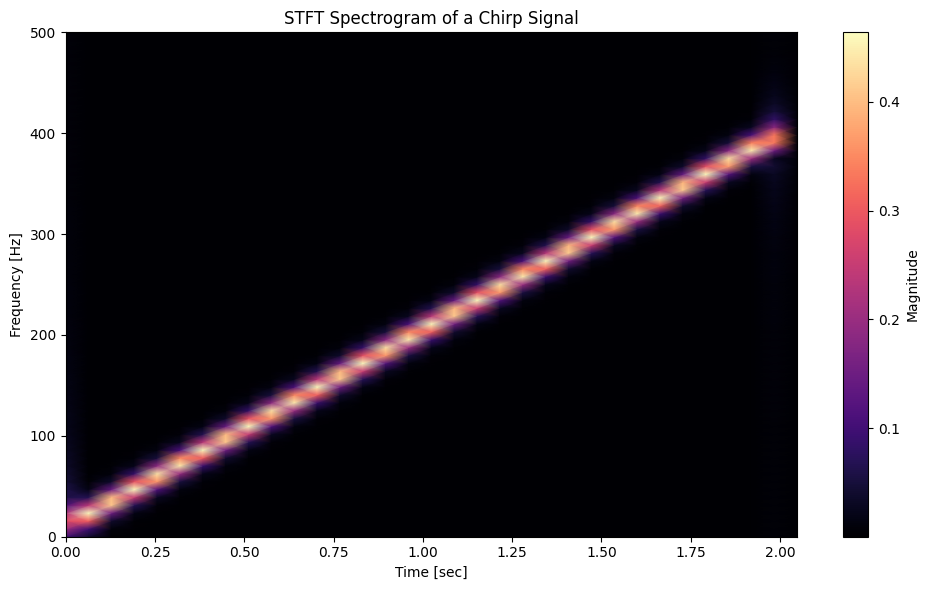

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Generate a "Chirp" signal (frequency increases over time)
fs = 1000  # Sampling frequency (1000 samples per second)
t = np.linspace(0, 2, 2 * fs)  # 2 seconds of time
x = signal.chirp(t, f0=10, f1=400, t1=2, method='linear')

# 2. Compute the STFT
# nperseg is the window length (how many samples per "slice")
frequencies, times, Zxx = signal.stft(x, fs, nperseg=128)

# 3. Plot the Spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(times, frequencies, np.abs(Zxx), shading='gouraud', cmap='magma')
plt.title('STFT Spectrogram of a Chirp Signal')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Magnitude')
plt.tight_layout()
plt.show()

example of a scalogram (Wavelets)

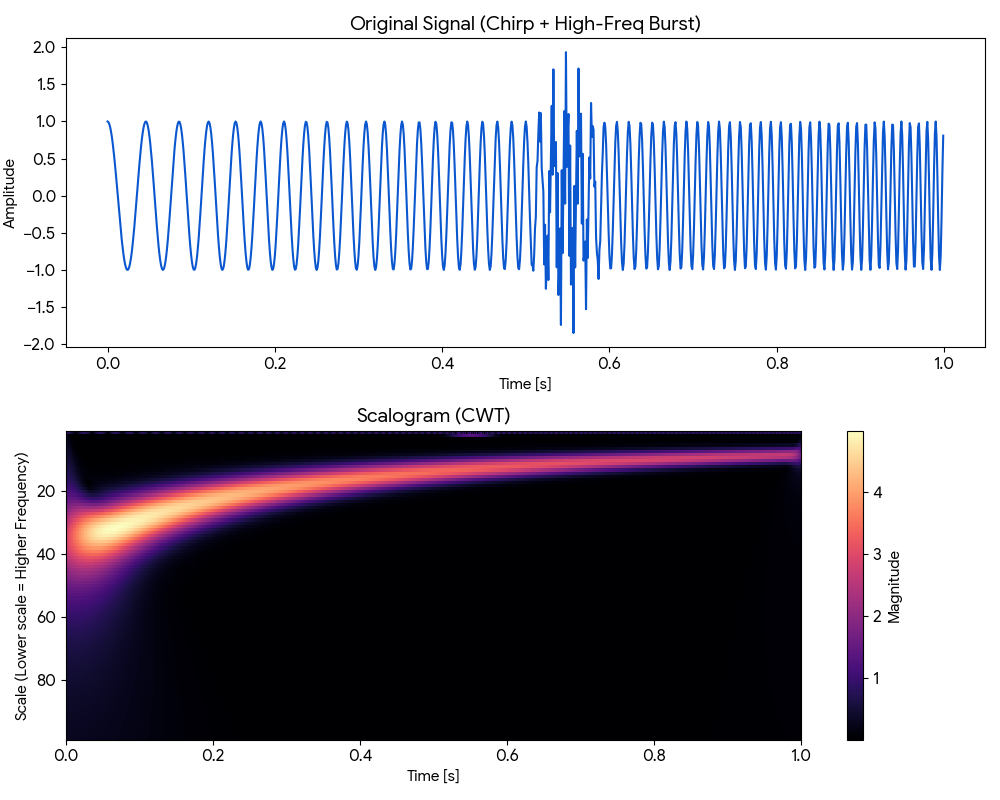

FFT

In [26]:
eeg1_frequency = fft(eeg1_scaled.flatten())

Text(0.5, 1.0, 'Frequency Spectrum')

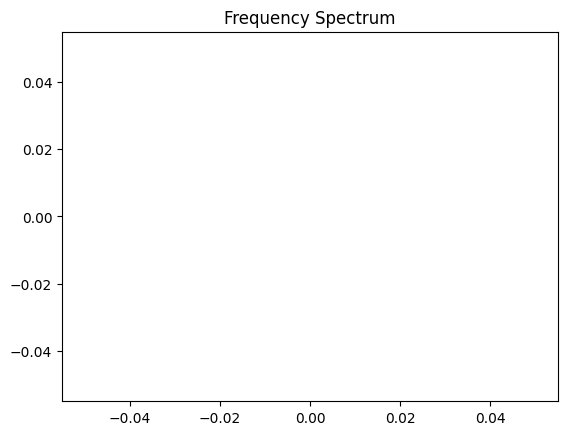

In [27]:
n = len(eeg1_frequency)
f = fftfreq(n, d=1/128)

plt.plot(f[:n//2], np.abs(eeg1_frequency[:n//2]))
plt.title("Frequency Spectrum")

Wavelets

In [ ]:
fs = 128
eeg1_flat = eeg1_scaled.flatten()

scales = np.arange(1,64)

coeffs, freqs = pywt.cwt(eeg1_flat, scales, wavelet='cmor1.5-1.0', sampling_period=1/fs)

power = (np.abs(coeffs)) ** 2

# it took 24 secoonds to compute this!!!

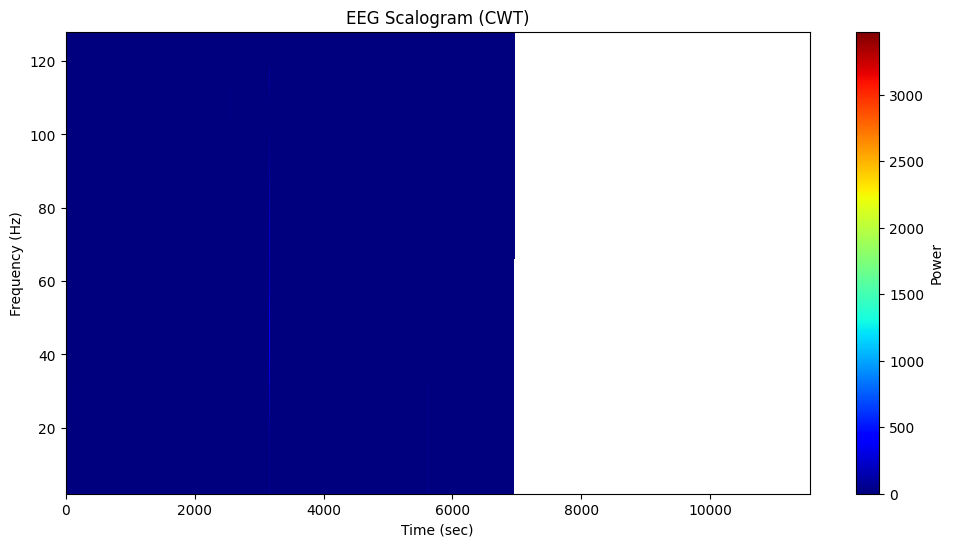

In [31]:
plt.figure(figsize=(12, 6))
plt.imshow(power, extent=[0, len(eeg1_flat)/fs, freqs[-1], freqs[0]], 
           cmap='jet', aspect='auto', interpolation='nearest')
plt.colorbar(label='Power')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (sec)')
plt.title('EEG Scalogram (CWT)')
plt.show()

# Dataset functions

In [16]:
def load_normalized_eeg_samples(path, seq_len, features):
    df = pd.read_csv(path)
    x = []
    x_means = {}
    x_stds = {}
    for f in features:
        x_f = df[f]
        x_f_mean = np.mean(x_f)
        x_f_std = np.std(x_f)
        x_f_z = [(x_fi - x_f_mean)/x_f_std for x_fi in x_f]
        x.append(x_f_z)
        x_means[f] = x_f_mean
        x_stds[f] = x_f_std
    
    x_z = np.stack(x, axis=1)
    X = np.array([x_z[i:i+seq_len] for i in range(x_z.shape[0]-seq_len)])
    X = X.reshape(-1, seq_len, len(features))

    y = df.bis
    Y = np.array([y[i+seq_len] for i in range(len(y)-seq_len)]).reshape(-1, 1)

    return X, Y, x_means, x_stds

In [17]:
def load_normalized_eeg_train(path, split, seq_len, features):
    X, Y, x_means, x_stds = load_normalized_eeg_samples(path, seq_len, features)
    split_idx = int(len(X) * split)
    return X[:split_idx], Y[:split_idx], x_means, x_stds

In [18]:
path = '../data/processed/eeg_sample.csv'
split = 0.8
seq_len = 200
features = ['delta','theta','alpha','beta']
X_train, Y_train, x_means, x_stds = load_normalized_eeg_train(path, split, seq_len, features)

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/eeg_sample.csv'

# Weird 3D plots

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # 1. Isolate the relevant EEG data
# eeg_columns = ['eeg1', 'eeg2']
# eeg_data = p[eeg_columns]

# # 2. Setup the figure
# fig = plt.figure(figsize=(12, 8))
# ax = fig.add_subplot(111, projection='3d')

# # 3. Create the Meshgrid
# x_indices = np.arange(eeg_data.shape[0])
# y_indices = np.arange(len(eeg_columns))
# x, y = np.meshgrid(x_indices, y_indices)

# # 4. Prepare data for plotting
# # FLATTEN EVERYTHING to ensure shapes match (4618,)
# x_plot = x.flatten()
# y_plot = y.flatten()
# z_plot = eeg_data.values.T.flatten()

# # 5. Plot the 3D scatter
# # Now x, y, and z all have the same 1D shape
# scatter = ax.scatter(x_plot, y_plot, z_plot, c=z_plot, cmap='viridis', marker='o', alpha=0.6)

# # 6. Formatting
# ax.set_xlabel('Time Index')
# ax.set_ylabel('Channels')
# ax.set_zlabel('Amplitude (µV)')
# ax.set_yticks(y_indices)
# ax.set_yticklabels(eeg_columns)

# plt.colorbar(scatter, label='µV', shrink=0.5)
# plt.show()

In [ ]:
# # Create the figure
# fig = plt.figure(figsize=(12, 8))
# ax = fig.add_subplot(111, projection='3d')

# # Plot each channel as a separate line
# for i, col in enumerate(eeg_columns):
#     # x = time, y = channel index, z = data
#     ax.plot(np.arange(len(eeg_data)), [i] * len(eeg_data), eeg_data[col], label=col, alpha=0.8)

#     # # Re-using the meshgrid (x, y) from the previous fix
#     # # Note: we don't flatten for wireframe!
#     # ax.plot_wireframe(x, y, eeg_data.values.T, rstride=0, cstride=10, color='teal', alpha=0.5)

#     # # You can also add a 'zero' plane to see when the signal goes negative
#     # ax.plot_surface(x, y, np.zeros_like(x), alpha=0.2, color='gray')

# ax.set_yticks([0, 1])
# ax.set_yticklabels(eeg_columns)
# ax.set_zlabel('µV')
# ax.set_title('3D EEG Signal Trace')
# plt.legend()
# plt.show()

In [3]:
path = '../data/processed/cases_data.csv'

df = pd.read_csv(path)
df.head()

,caseid,optype,sex,age,asa,bmi,preop_hb,preop_k,preop_na,preop_gluc,preop_cr,preop_alb,propofol,volatile,remifentanil
0,36,Breast,F,38.0,1.0,20.7,12.9,4.5,139.0,93.0,0.63,4.6,True,True,True
1,100,Colorectal,F,58.0,2.0,19.6,13.9,3.8,143.0,102.0,0.79,4.1,False,True,False
2,141,Breast,F,54.0,1.0,24.6,12.8,4.5,141.0,58.0,0.75,4.2,True,True,True
3,169,Thyroid,F,69.0,2.0,23.0,12.8,4.0,141.0,106.0,0.68,4.2,True,True,True
4,173,Colorectal,M,53.0,2.0,19.1,10.8,4.6,138.0,135.0,0.84,3.5,False,True,False
